In [1]:
%load_ext autoreload
%autoreload 2

In [9]:
from data_preprocessing import load_dataset

dataset_easy = load_dataset("datasets/E4A_1-1.data")
dataset_medium = load_dataset("datasets/E4A_2-8.data")
dataset_hard = load_dataset("datasets/E4A_9-64.data")

Dataset E4A_1-1.data cargado con 1000 muestras.
Dataset E4A_2-8.data cargado con 1000 muestras.
Dataset E4A_9-64.data cargado con 763 muestras.


In [19]:
from models.CLPTransformer import CLPTransformer

# Parámetros del modelo
blocks_dim = 5
action_dim = 2
placed_dim = 3
d_model = 32
nhead = 4
num_layers = 2
dropout = 0.1

# Crear modelo
model = CLPTransformer(
    block_dim=blocks_dim,
    action_dim=action_dim,
    placed_dim=placed_dim,
    d_model=d_model,
    nhead=nhead,
    num_layers=num_layers,
    dropout=dropout
)

In [20]:
from training import train

epochs = 3
datasets = [dataset_easy, dataset_medium, dataset_hard]
train_size = 200
train_weights = [1, 1, 1]
test_size = 100
test_weights = [1, 1, 1]
batch_size = 32
learning_rate = 1e-4
seed = 42

stats = train(model, epochs, datasets, train_size, train_weights, test_size, test_weights, batch_size, learning_rate, seed)

ℹ️ Usando dispositivo: cpu
ℹ️ Iniciando fase: 1/3
Epoch 1/3 - Train Loss: 4.1577, Train Accuracy: 7.50% - Val Loss: 4.1575, Val Accuracy: 66.67%
    Test Set: E4A_1-1.data - Val Loss: 4.1575, Val Accuracy: 66.67%
    Test Set: E4A_2-8.data - Val Loss: 4.1582, Val Accuracy: 9.09%
    Test Set: E4A_9-64.data - Val Loss: 4.1589, Val Accuracy: 0.00%
    Weighted - Val Loss: 4.1582, Val Accuracy: 25.25%
Epoch 2/3 - Train Loss: 4.1577, Train Accuracy: 4.50% - Val Loss: 4.1571, Val Accuracy: 66.67%
    Test Set: E4A_1-1.data - Val Loss: 4.1571, Val Accuracy: 66.67%
    Test Set: E4A_2-8.data - Val Loss: 4.1580, Val Accuracy: 9.09%
    Test Set: E4A_9-64.data - Val Loss: 4.1589, Val Accuracy: 0.00%
    Weighted - Val Loss: 4.1580, Val Accuracy: 25.25%
Epoch 3/3 - Train Loss: 4.1571, Train Accuracy: 4.50% - Val Loss: 4.1565, Val Accuracy: 60.61%
    Test Set: E4A_1-1.data - Val Loss: 4.1565, Val Accuracy: 60.61%
    Test Set: E4A_2-8.data - Val Loss: 4.1576, Val Accuracy: 12.12%
    Test Set: E

In [21]:
from training import save_model

model_name = "CLPTransformer"
save_model(model, model_name)

✅ Modelo guardado en /home/oscar/CLP-Framework/models/CLPTransformer.pth


In [22]:
from training import load_model

model = load_model(CLPTransformer, model_name)

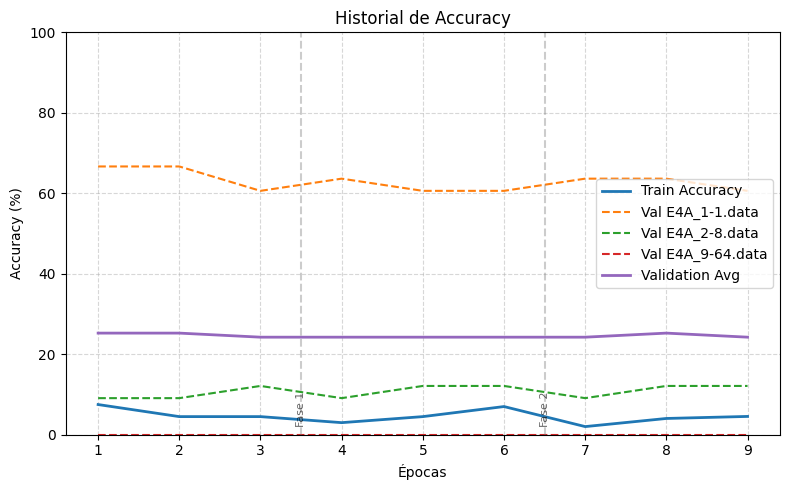

In [23]:
stats.plot()